# scRNA-seq Normalization

Place the quality-controlled input dataset at `data/s4d8_quality_control.h5ad` before running the notebook.

This notebook compares three normalization approaches:

1. Shifted logarithm
2. Scran size-factor normalization
3. Analytic Pearson residuals


In [ ]:
# Import analysis packages and configure Scanpy
from pathlib import Path
import logging

import numpy as np
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc
import seaborn as sns
from matplotlib import pyplot as plt
from rpy2.robjects import numpy2ri, pandas2ri
from rpy2.robjects.conversion import localconverter
from scipy.sparse import csr_matrix, issparse

# Suppress verbose logging from Scanpy
sc.settings.verbosity = 0

# Set figure parameters for clean, minimal plots
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

# Suppress verbose logging from rpy2
rcb.logger.setLevel(logging.ERROR)


In [ ]:
# Enable R cells in Jupyter
%load_ext rpy2.ipython


In [ ]:
# Load the quality-controlled AnnData dataset
DATA_PATH = Path("data/s4d8_quality_control.h5ad")
adata = sc.read_h5ad(DATA_PATH)
adata


AnnData object with n_obs × n_vars = 14814 × 20121
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'soupx_groups', 'scDblFinder_score', 'scDblFinder_class'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: 'counts', 'soupX_counts'

## Count-depth distribution

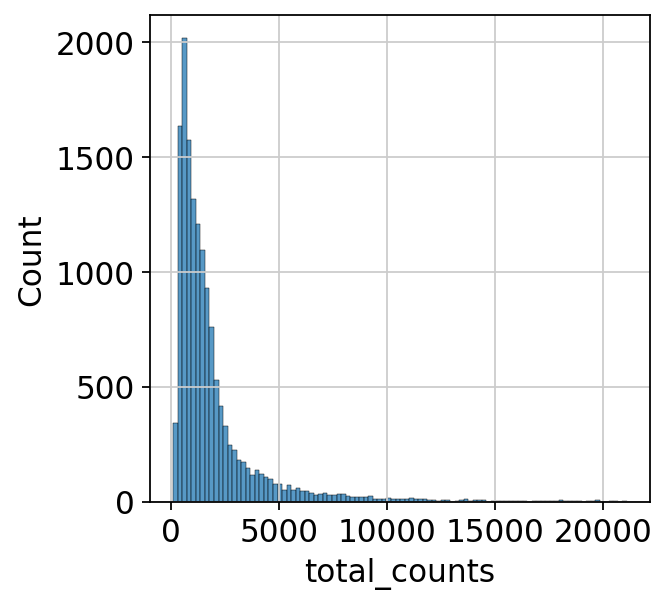

In [ ]:
# Visualize total counts per cell before normalization
p1 = sns.histplot(
    adata.obs["total_counts"],
    bins=100,
    kde=False,
)


## Shifted logarithm

In [ ]:
# Normalize each cell by its total count and apply log1p
scaled_counts = sc.pp.normalize_total(
    adata,
    target_sum=None,
    inplace=False,
)

adata.layers["log1p_norm"] = sc.pp.log1p(
    scaled_counts["X"],
    copy=True,
)


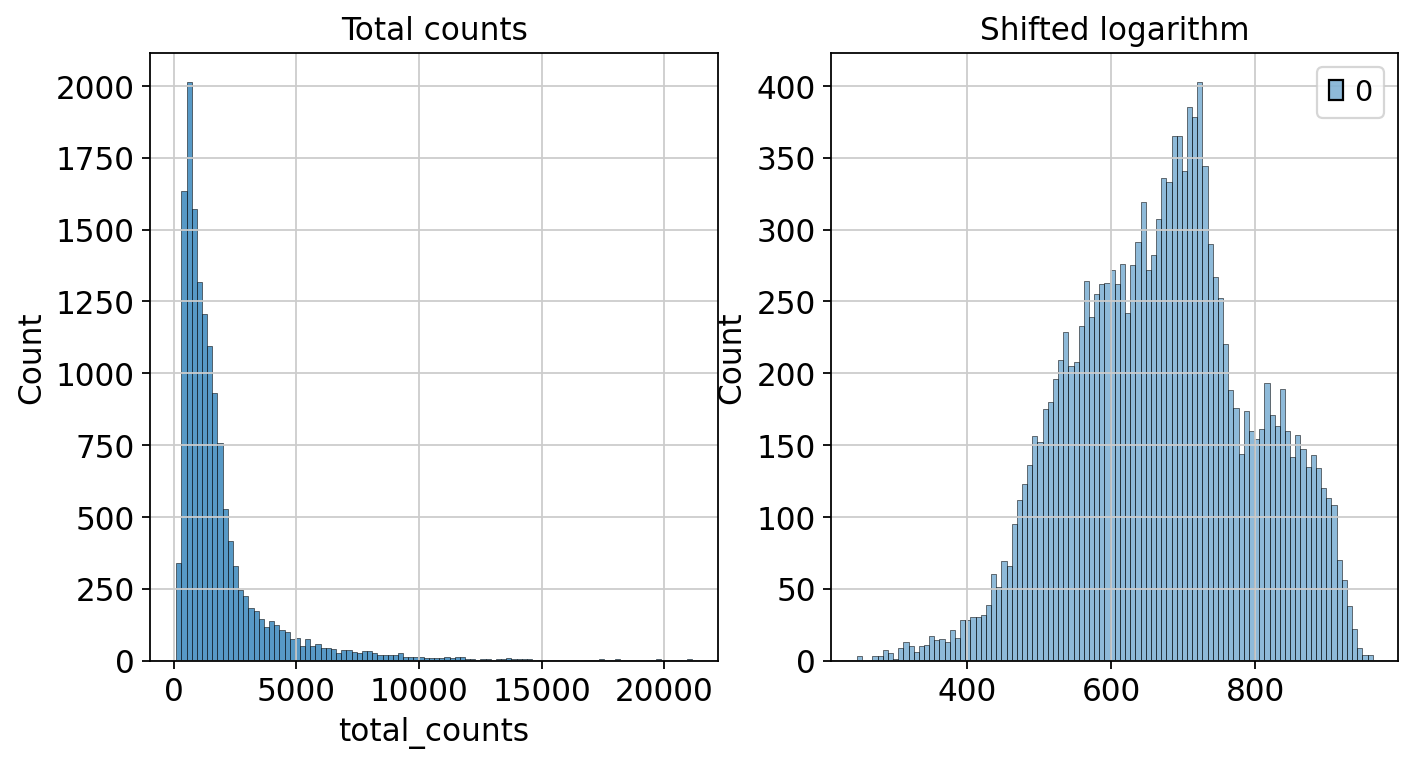

In [ ]:
# Compare total counts with shifted-log normalized values
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

p1 = sns.histplot(
    adata.obs["total_counts"],
    bins=100,
    kde=False,
    ax=axes[0],
)
axes[0].set_title("Total counts")

p2 = sns.histplot(
    adata.layers["log1p_norm"].sum(1),
    bins=100,
    kde=False,
    ax=axes[1],
)
axes[1].set_title("Shifted logarithm")

plt.show()


## Scran normalization

In [ ]:
%%R
# Load R packages required for Scran normalization
library(scran)
library(BiocParallel)


In [ ]:
# Build preliminary Leiden clusters for Scran
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(
    adata_pp,
    key_added="groups",
    flavor="igraph",
    n_iterations=2,
    directed=False,
)


In [ ]:
# Prepare raw counts and cluster labels for transfer to R
# Scran requires raw counts rather than normalized or log-transformed values.
data_mat = adata.layers["counts"].T

if issparse(data_mat):
    if data_mat.nnz > 2**31 - 1:
        data_mat = data_mat.tocoo()
    else:
        data_mat = data_mat.tocsc()

    # Convert the sparse matrix to a dense NumPy array for rpy2 transfer.
    data_mat = data_mat.toarray()

with localconverter(ro.default_converter + numpy2ri.converter):
    ro.globalenv["data_mat"] = data_mat

with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv["input_groups"] = adata_pp.obs["groups"]


In [ ]:
# Remove the temporary clustering object
del adata_pp


In [ ]:
%%R -o size_factors
# Estimate cell-specific size factors with Scran
size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts = data_mat)
        ),
        clusters = input_groups,
        min.mean = 0.1,
        BPPARAM = MulticoreParam()
    )
)


In [ ]:
# Apply the Scran size factors and store the log-normalized matrix
adata.obs["size_factors"] = size_factors
scran = adata.X / adata.obs["size_factors"].values[:, None]
scran_logged = np.log1p(scran)
adata.layers["scran_normalization"] = csr_matrix(scran_logged)


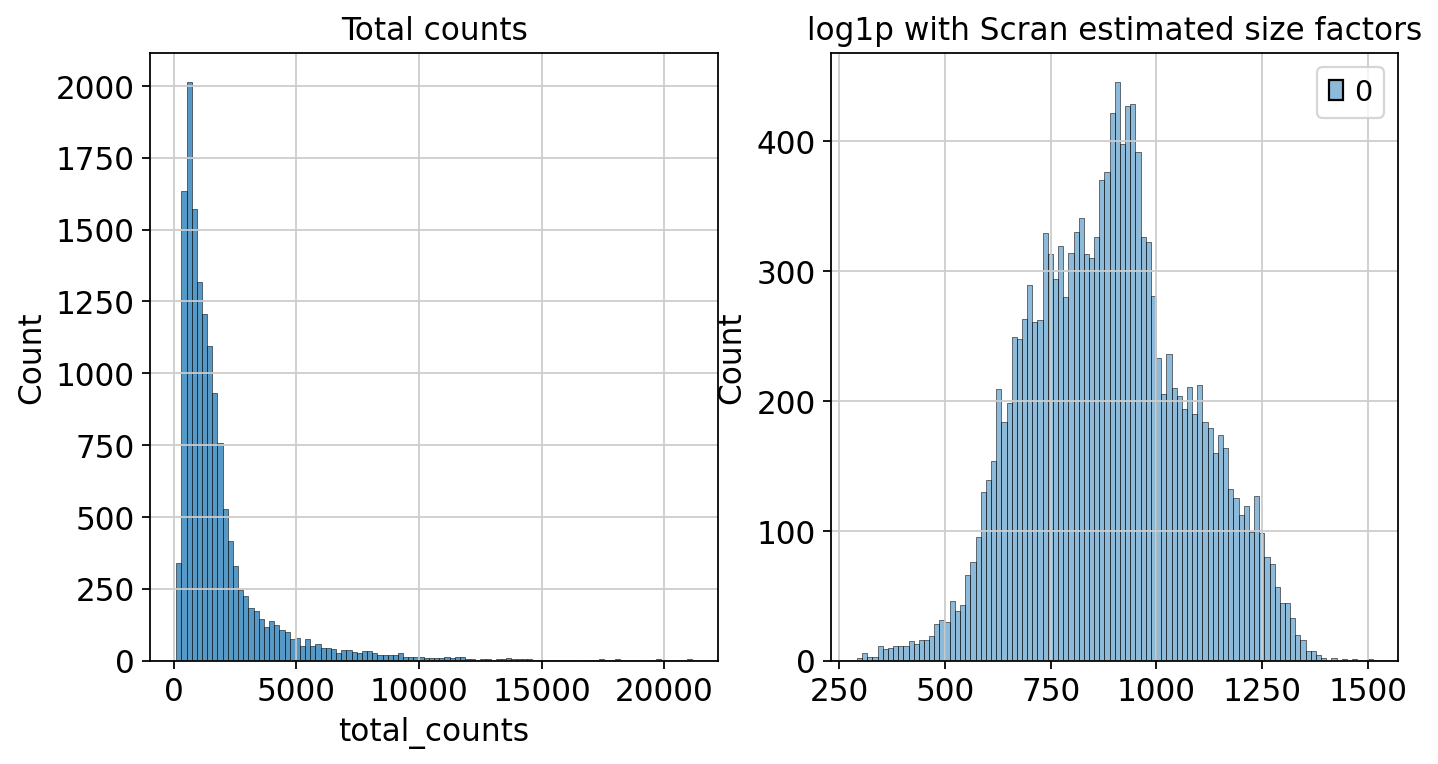

In [ ]:
# Compare total counts with Scran-normalized values
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

p1 = sns.histplot(
    adata.obs["total_counts"],
    bins=100,
    kde=False,
    ax=axes[0],
)
axes[0].set_title("Total counts")

p2 = sns.histplot(
    adata.layers["scran_normalization"].sum(1),
    bins=100,
    kde=False,
    ax=axes[1],
)
axes[1].set_title("log1p with Scran estimated size factors")

plt.show()


## Analytic Pearson residuals

In [ ]:
# Calculate analytic Pearson residuals from the raw count matrix
analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(
    adata,
    inplace=False,
)

adata.layers["analytic_pearson_residuals"] = csr_matrix(
    analytic_pearson["X"]
)


In [ ]:
# Compare total counts with analytic Pearson residuals
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

p1 = sns.histplot(
    adata.obs["total_counts"],
    bins=100,
    kde=False,
    ax=axes[0],
)
axes[0].set_title("Total counts")

p2 = sns.histplot(
    adata.layers["analytic_pearson_residuals"].sum(1),
    bins=100,
    kde=False,
    ax=axes[1],
)
axes[1].set_title("Analytic Pearson residuals")

plt.show()


## Save normalized data

In [ ]:
# Save the AnnData object with all normalization layers
OUTPUT_PATH = Path("results/s4d8_normalization.h5ad")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(OUTPUT_PATH)
